### GENERAL

While EDA could be completed with the entirity of the AHR dataset before trimming, the other two datasets selected (NHIS and NSDUH) were incredibly comprehensive in scope--so much so that their codebooks had to be inspected to determine which columns pertained to our goals and which were irrelevant. To ensure optimal runtimes downstream and clear data presentation, the fewest amount of columns that would still allow us to reach our goals were selected. Based on current and emerging literature, data on the following were deemed pertinent:
* asthma
* cancer (broadly)
* mental health concerns (broadly)
* sleep quality/frequency

Column IDs and descriptions can be found in the following: https://drexel0-my.sharepoint.com/:x:/g/personal/mnm343_drexel_edu/IQBGy-KcC2veQ7Uf_kaVubpQAcvW-77wa_GwGG9H3Kp_pZ0?e=uRC7YZ

### AHR Data

In [ ]:
# remember to upload to files when rerunning or else the code breaks
import pandas as pd
# encoding specified due to special characters
df = pd.read_csv('2025 annual report - report data (all states)_12.12.csv', encoding='windows-1252')

/tmp/ipykernel_1021/3325977793.py:4: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('2025 annual report - report data (all states)_12.12.csv', encoding='windows-1252')


In [ ]:
df.head()

,Report,Measure,State,Value,Score,Rank,LowerCI,UpperCI,Source,Data Year(s)
0,2025 Annual,Social and Economic Factors,AK,0.043,0.043,28.0,NaN,NaN,America's Health Rankings composite measure,2025
1,2025 Annual,Social and Economic Factors,AL,-0.662,-0.662,44.0,NaN,NaN,America's Health Rankings composite measure,2025
2,2025 Annual,Social and Economic Factors,ALL,NaN,NaN,NaN,NaN,NaN,America's Health Rankings composite measure,2025
3,2025 Annual,Social and Economic Factors,AR,-0.933,-0.933,48.0,NaN,NaN,America's Health Rankings composite measure,2025
4,2025 Annual,Social and Economic Factors,AZ,0.086,0.086,25.0,NaN,NaN,America's Health Rankings composite measure,2025


In [ ]:
df.shape

(82054, 10)

In [ ]:
# dropping rows where state is 'ALL' since that doesn't really help us here
# also dropping DC because it has no data
df = df[(df['State'] != 'ALL') | (df['State'] != 'DC')]

In [ ]:
# printing NaN percents to see if there's any columns we should drop
rows = df.shape[0]

for col in df.columns.tolist():
  print(f"\u2001{col} NaN percent: {sum(df[col].isna())/rows *100: .4f}%")

 Report NaN percent:  0.0000%
 Measure NaN percent:  0.0000%
 State NaN percent:  0.0000%
 Value NaN percent:  15.5227%
 Score NaN percent:  94.6462%
 Rank NaN percent:  23.8172%
 LowerCI NaN percent:  22.6534%
 UpperCI NaN percent:  22.6534%
 Source NaN percent:  0.0000%
 Data Year(s) NaN percent:  0.0000%


In [ ]:
# dropping score; tentative on CI since I don't really think it means all that much
# also dropping source since it's not important
df = df.drop(columns = ['Score', 'Source', 'Value', 'LowerCI', 'UpperCI',])

In [ ]:
df.shape

(82054, 5)

In [ ]:
state_avg_ranking = df.groupby('State')['Rank'].mean().sort_values(ascending=True)

In [ ]:
print(state_avg_ranking)

State
MA     14.238705
NH     15.768392
MN     16.195794
CT     16.210652
MD     16.914328
NJ     16.919417
VT     16.976015
HI     17.208130
UT     17.784450
RI     18.699078
WA     18.949785
CO     19.736641
CA     19.899319
NY     20.104198
ND     20.207155
NE     20.666128
ID     20.735786
NC     20.741113
IA     20.874804
VA     21.016591
WI     21.307180
SD     22.269484
IL     23.331625
ME     23.437448
AK     24.084211
PA     24.200333
MT     24.296266
DE     24.301695
KS     24.309309
TX     24.331875
AZ     24.552749
OR     24.991413
FL     25.034776
NM     25.058775
MI     25.457416
GA     26.151198
SC     26.551752
MO     26.635665
WY     26.818512
IN     27.239882
OH     27.958883
TN     29.119522
NV     29.710422
MS     30.056750
OK     30.805599
AL     31.798280
LA     31.883473
KY     32.164205
AR     32.553945
WV     35.359741
ALL          NaN
DC           NaN
Name: Rank, dtype: float64


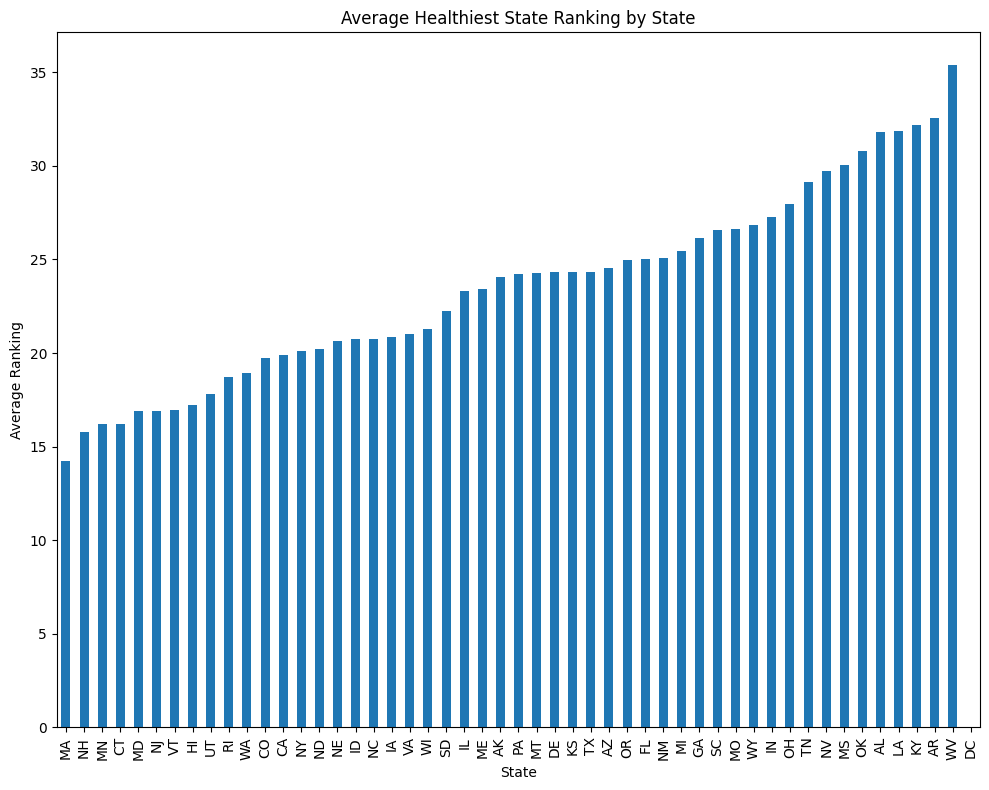

In [ ]:
import matplotlib.pyplot as plt

state_avg_ranking.sort_values().plot(kind='bar', figsize=(10, 8))
plt.ylabel('Average Ranking')
plt.title('Average Healthiest State Ranking by State')
plt.tight_layout()
plt.show()
# not the best for this but just to get an idea

In [ ]:
# how much of the data are from 2025/4/etc.
# tried converting to DT object but some are ranges
search = df['Data Year(s)'].unique()

counts = df['Data Year(s)'][df['Data Year(s)'].isin(search)].value_counts()
print(counts)
# dates are messed up and inconsistent; will have to clean text and drop range data
# but we can see most of the data are from 2024... should we keep just that?

Data Year(s)
2024                      44010
2024                      12098
2023                       8422
2025                       5668
2023                       4368
2022                       1924
2023-2024                  1300
2021                       1196
2022-2023                   988
2021-2023                   884
2017-2021                   312
2021-2022 School Year       312
1-Sep                       156
2019-2023                   104
2020-2022                    52
2022/2024                    52
2022-2024                    52
2020                         52
2020-2021 Birth Cohort       52
2025                         52
Name: count, dtype: int64


In [ ]:
# purging spaces
df['Data Year(s)'] = df['Data Year(s)'].str.replace(r'^\s+|\s+$', ' ', regex=True)

In [ ]:
# can also include 2025 but only marginally increases
df_2024only = df[(df['Data Year(s)'] == '2024')]

df_2024only.head()

,Report,Measure,State,Rank,Data Year(s)
2132,2025 Annual,Economic Hardship Index,AK,18.0,2024
2133,2025 Annual,Economic Hardship Index,AL,41.0,2024
2134,2025 Annual,Economic Hardship Index,ALL,NaN,2024
2135,2025 Annual,Economic Hardship Index,AR,44.0,2024
2136,2025 Annual,Economic Hardship Index,AZ,36.0,2024


In [ ]:
df_2024only.shape

(44010, 5)

In [ ]:
df_2024only = df_2024only[(df_2024only['State'] != 'ALL') | (df_2024only['State'] != 'DC')]

In [ ]:
avgrank_24 = df_2024only.groupby('State')['Rank'].mean()
rankdf = avgrank_24.to_frame(name="Values").reset_index()

In [ ]:
rankdf = rankdf.dropna(subset=['Values'])
print(rankdf)

   State     Values
0     AK  26.290984
1     AL  30.928571
3     AR  32.990071
4     AZ  25.871863
5     CA  21.705479
6     CO  21.936658
7     CT  15.142265
9     DE  21.945985
10    FL  26.090656
11    GA  26.080795
12    HI  16.544837
13    IA  21.908725
14    ID  23.629738
15    IL  23.375321
16    IN  26.367609
17    KS  24.919689
18    KY  31.827881
19    LA  30.234270
20    MA  13.859603
21    MD  14.095731
22    ME  23.342291
23    MI  24.395046
24    MN  16.105732
25    MO  26.567935
26    MS  28.275915
27    MT  28.053719
28    NC  18.645517
29    ND  20.689510
30    NE  22.451253
31    NH  15.375000
32    NJ  17.623306
33    NM  26.033382
34    NV  29.855319
35    NY  19.476510
36    OH  28.018106
37    OK  31.708618
38    OR  26.830320
39    PA  23.434483
40    RI  18.150492
41    SC  25.438990
42    SD  23.004808
43    TN  29.881356
44    TX  26.483745
45    UT  19.859438
46    VA  21.024032
47    VT  18.100610
48    WA  19.579618
49    WI  21.553966
50    WV  32.867318


In [ ]:
# visualizing average rank with a map instead of another chart
import plotly.express as px

fig = px.choropleth(
    rankdf,
    locations='State',
    locationmode='USA-states',
    color='Values',
    width=1000,
    height=600,
    hover_name='State',
    color_continuous_scale='RdYlGn_r', # Green for high rank (low number), Red for low rank
    scope='usa',
    title='U.S. States Average Health Ranking for 2024'
)

fig.show()

# displaying the

In [ ]:
import numpy as np
np.set_printoptions(threshold=np.inf)

print(df_2024only['Measure'].unique())

'''
really granular, I feel like it would be best to only keep the measures where
env. conditions caused by data centers (like asthma or forms of cancer).

plan is to ultimately  remove uneccessary measures and take the average of the score for
all afflicted groups by state and present it as "(x) state is (x) rank for
(x affliction), which could be worsened by the pollution caused by data centers"

MORE research will be needed so we can say this confidently but there
are definitely papers to pull from esp for asthma:

https://pmc.ncbi.nlm.nih.gov/articles/PMC12273412/
https://www.environmentalhealthproject.org/post/the-dangers-of-data-centers
'''

['Economic Hardship Index' 'Crowded Housing' 'Crowded Housing - Black'
 'Crowded Housing - Hispanic' 'Crowded Housing - White'
 'Dependency (Ages <18 or >64)' 'Dependency (Ages <18 or >64) - Black'
 'Dependency (Ages <18 or >64) - Hispanic'
 'Dependency (Ages <18 or >64) - White' 'Less Than High School Education'
 'Education - Less Than High School - Black'
 'Education - Less Than High School - Hispanic'
 'Education - Less Than High School - White' 'Per Capita Income'
 'Per Capita Income - Black' 'Per Capita Income - Hispanic'
 'Per Capita Income - White' 'Poverty' 'Unemployment'
 'Unemployment - Black' 'Unemployment - Hispanic' 'Unemployment - White'
 'Homeownership' 'Homeownership Racial Disparity'
 'Homeownership - American Indian/Alaska Native' 'Homeownership - Asian'
 'Homeownership - Black' 'Homeownership - Hawaiian/Pacific Islander'
 'Homeownership - Hispanic' 'Homeownership - Multiracial'
 'Homeownership - Other Race' 'Homeownership - White' 'Income Inequality'
 'Fourth Grade R

'\nreally granular, I feel like it would be best to only keep the measures where\nenv. conditions caused by data centers (like asthma or forms of cancer).\n\nplan is to remove uneccessary measures and take the average of the score for\nall afflicted groups by state and present it as "(x) state is (x) rank for\n(x affliction), which could be worsened by the pollution caused by data centers"\n\nultimately MORE research will be needed so we can say this confidently but there\nare definitely papers to pull from esp for asthma:\n\nhttps://pmc.ncbi.nlm.nih.gov/articles/PMC12273412/\nhttps://www.environmentalhealthproject.org/post/the-dangers-of-data-centers\n'

### NHIS

In [ ]:
# this is for NHIS
import pandas as pd
# encoding specified due to special characters
dfnhis = pd.read_csv('adult24.csv', encoding='windows-1252', low_memory=False)

In [ ]:
dfnhis.head()

,RATCAT_A,INCTCFLG_A,IMPINCFLG_A,PPSU,PSTRAT,WLKLEISTC_A,WLKTRANTC_A,HISPALLP_A,RACEALLP_A,ANYDIFF_A,...,LSATIS4_A,PHSTAT_A,HHSTAT_A,INTV_MON,RECTYPE,IMPNUM_A,AVGNUMCIG_A,WTFA_A,HHX,POVRATTC_A
0,9,0,2,2,122,NaN,NaN,2,1,2,...,1,1,1,1,10,1,30,5780.565,H067658,2.82
1,8,0,0,2,122,20.0,NaN,2,1,2,...,2,2,1,1,10,1,20,3994.244,H076577,2.01
2,7,0,0,2,122,30.0,NaN,2,1,1,...,1,2,1,1,10,1,20,6636.755,H019335,1.90
3,12,0,0,2,122,10.0,NaN,2,1,1,...,2,3,1,1,10,1,01,13767.420,H012701,4.48
4,14,0,0,1,115,NaN,NaN,3,2,1,...,2,3,1,1,10,1,NaN,18880.030,H049678,6.37


In [ ]:
dfnhis.shape
# ZAYUM

(32629, 630)

In [ ]:
dfnhis_refined = dfnhis[['REGION', 'URBRRL23', 'HHX', 'DXRESP_A','HLTHCOND_A', 'MEDRXTRT_A',
                         'COPDEV_A', 'CANEV_A', 'ASEV_A','SLPREST_A', 'DEPEV_A', 'ANXEV_A']]

In [ ]:
dfnhis_refined.head()

,REGION,URBRRL23,HHX,DXRESP_A,HLTHCOND_A,MEDRXTRT_A,COPDEV_A,CANEV_A,ASEV_A,SLPREST_A,DEPEV_A,ANXEV_A
0,3,4,H067658,NaN,2,2,2,2,2,3,2,2
1,3,4,H076577,NaN,2,2,2,2,2,3,2,2
2,3,4,H019335,2.0,2,2,1,2,2,4,2,2
3,3,4,H012701,2.0,2,2,2,2,2,2,2,1
4,3,2,H049678,1.0,2,2,2,2,1,3,1,1


In [ ]:
rows = dfnhis_refined.shape[0]

for col in dfnhis_refined.columns.tolist():
  print(f"\u2001{col} NaN percent: {sum(dfnhis_refined[col].isna())/rows *100: .4f}%")
# removed still have asthma bc that is just high NaN, verdict out on allergies... may impute if substantial research

 REGION NaN percent:  0.0000%
 URBRRL23 NaN percent:  0.0000%
 HHX NaN percent:  0.0000%
 DXRESP_A NaN percent:  50.5685%
 HLTHCOND_A NaN percent:  0.0000%
 MEDRXTRT_A NaN percent:  0.0000%
 COPDEV_A NaN percent:  0.0000%
 CANEV_A NaN percent:  0.0000%
 ASEV_A NaN percent:  0.0000%
 SLPREST_A NaN percent:  0.0000%
 DEPEV_A NaN percent:  0.0000%
 ANXEV_A NaN percent:  0.0000%


In [ ]:
dfnhis_refined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32629 entries, 0 to 32628
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   REGION      32629 non-null  int64  
 1   URBRRL23    32629 non-null  int64  
 2   HHX         32629 non-null  object 
 3   DXRESP_A    16129 non-null  float64
 4   HLTHCOND_A  32629 non-null  int64  
 5   MEDRXTRT_A  32629 non-null  int64  
 6   ARTHEV_A    32629 non-null  int64  
 7   COPDEV_A    32629 non-null  int64  
 8   CANEV_A     32629 non-null  int64  
 9   ASEV_A      32629 non-null  int64  
 10  SLPREST_A   32629 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 2.7+ MB


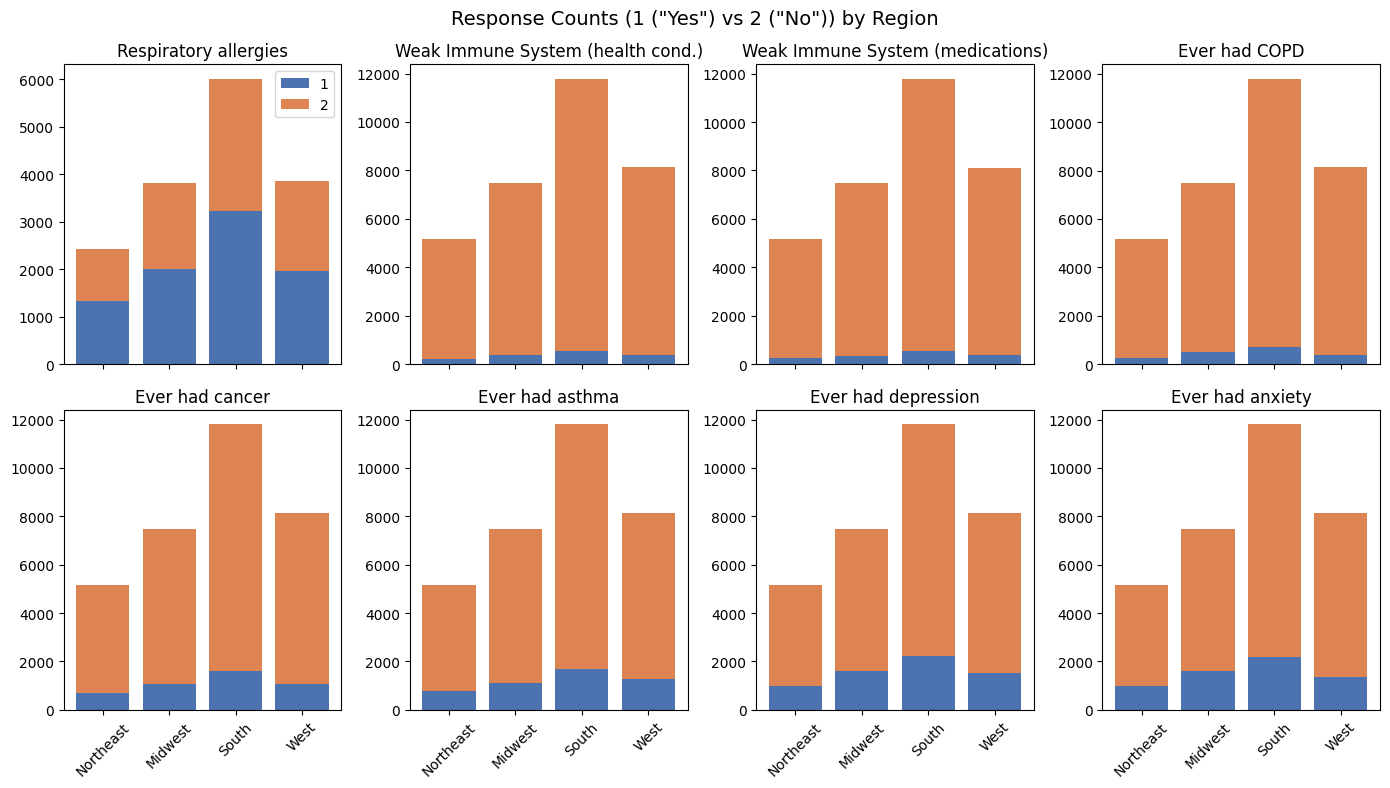

In [ ]:
# x axis is region
# from 1 - 4, Northeast, Midwest, South, West so we have imbalances between scores and regions
# had to remove sleep bc it has more than 1 and 2, which were hardcoded to only capture yes and no responses
import numpy as np
import matplotlib.pyplot as plt

cols = ['DXRESP_A', 'HLTHCOND_A', 'MEDRXTRT_A',
        'COPDEV_A', 'CANEV_A', 'ASEV_A', 'DEPEV_A', 'ANXEV_A']

regions = sorted(dfnhis_refined['REGION'].unique())

fig, axes = plt.subplots(2, 4, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, col in enumerate(cols):
    # count of 1s and 2s per region
    counts = dfnhis_refined.groupby('REGION')[col].value_counts().unstack(fill_value=0)
    counts = counts.reindex(regions)  # keeps region order consistent

    ax = axes[i]
    ax.bar(counts.index, counts[1], label='1', color='#4C72B0')
    ax.bar(counts.index, counts[2], bottom=counts[1], label='2', color='#DD8452') # I know for a fact I can see these colors

    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(['Northeast', 'Midwest', 'South', 'West'])


axes[0].legend()
fig.suptitle('Response Counts (1 ("Yes") vs 2 ("No")) by Region', fontsize=14)
fig.axes[0].set_title("Respiratory allergies")
fig.axes[1].set_title("Weak Immune System (health cond.)")
fig.axes[2].set_title("Weak Immune System (medications)")
fig.axes[3].set_title("Ever had COPD")
fig.axes[4].set_title("Ever had cancer")
fig.axes[5].set_title("Ever had asthma")
fig.axes[6].set_title("Ever had depression")
fig.axes[7].set_title("Ever had anxiety")

plt.tight_layout()
plt.show()


In [ ]:
# also have to do sleep separaately bc again different values
# but that doesn't feel the most important rn I'll do it later